In [9]:
import numpy as np
import scipy
import scipy.special
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt
from IPython.display import display
import threading
from io import StringIO 
import sys
import ipywidgets as widgets
import math
import cv2
import os

import plotly
import plotly.graph_objs as go

import diffractsim
diffractsim.set_backend("CPU")
from diffractsim import nm, mm, cm, um

from PIL import Image

Let's reproduce the OAM mode sorter posited by Robert Fickler et al. 

# Implementation w/ Angular Spectrum 

# Implementation using Functions

In [86]:
# Fresnel Propagator Function

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))
    
    
    return u2 


'''
This function implements the Fraufoner Diffraction Transfer Approach instead. Translation from Voelz
u1 - source field
L1 - full observation side length 
la - wavelength 
z - prop distance


returns: 
u2 - observation field at z
L2 - observation field side lengths
'''

def propFF(u1, L1, la, z):
    #Some initial calcs from the source field
    
    M, nn = np.shape(u1)
    dx1 = L1/M
    k = 2*np.pi/la
    
    # compute params for observation plane
    
    L2 = (la*z)/dx1
    dx2 = (la*z)/L1
    
    # compute field at observation plane 
    x2 = np.arange(-L2/2,L2/2,dx2)
    
    xx2, yy2 = np.meshgrid(x2, x2)
    
    # Fraufofner transfer function? 
    c = (1/(1j*la*z))*np.exp(1j*(k/2*z)*(xx2**2 + yy2**2))
    u2 = c*ifftshift(fft2(fftshift(u1)))*dx1**2
    
    return u2, L2


# LG modes 

'''
# Generates the normalized LG field.
# Expression adapted from Saleh. The normalization factor is adapted from wikipedia, 
# then modified silghtly so that the LG mode expression in wikipedia and Saleh are equivalent
#
# RHO, PHI - polar coordinate field
# ell - azimuthal index
# p - radial index
# w0 - beam waist (in units of ... w0)
# h - grid step size
# z - propagation distance
# k - wavenumber
'''

def LG(RHO,PHI,ell,p,w0,h,z,k):
    wL = (2*np.pi)/(k)
    z_o = np.pi*w0**2/wL
    w_z = lambda z: w0*np.sqrt(1 + (z/z_o)**2)
    R_z = lambda z: z*(1+(z_o/z)**2)
    zeta_z = lambda z: np.arctan(z/z_o)

    N_factor = 1
    if (z == 0):
        AK = N_factor * np.exp(-(RHO/w0)**2) * ((RHO/w0)**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w0)**2) * np.exp(1j * ell * phi))
    else:
        AK = N_factor * (w0/w_z(z)) * np.exp(-(RHO/w_z(z))**2) * ((RHO/w_z(z))**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w_z(z))**2) * np.exp(1j * ell * phi))*np.exp(-1j*k*z) * np.exp(-1j*k*(RHO**2/(2*R_z(z)))) * np.exp(1j*(abs(ell)+2*p + 1)*zeta_z(z))
    reNormFactor = np.sqrt(np.sum(np.conj(AK)*AK * h**2)) # We use this to further normalize the field with respect to 
    return  AK/reNormFactor


# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()
    
    
'''
Cartesian to Polar coordinates 
x,y - x and y coordinates
'''

def cart2pol(x, y):
    rho = np.sqrt((x)**2 + (y)**2)
    phi = np.arctan2(y, x)
    return(rho, phi)




Defining the coordinate space

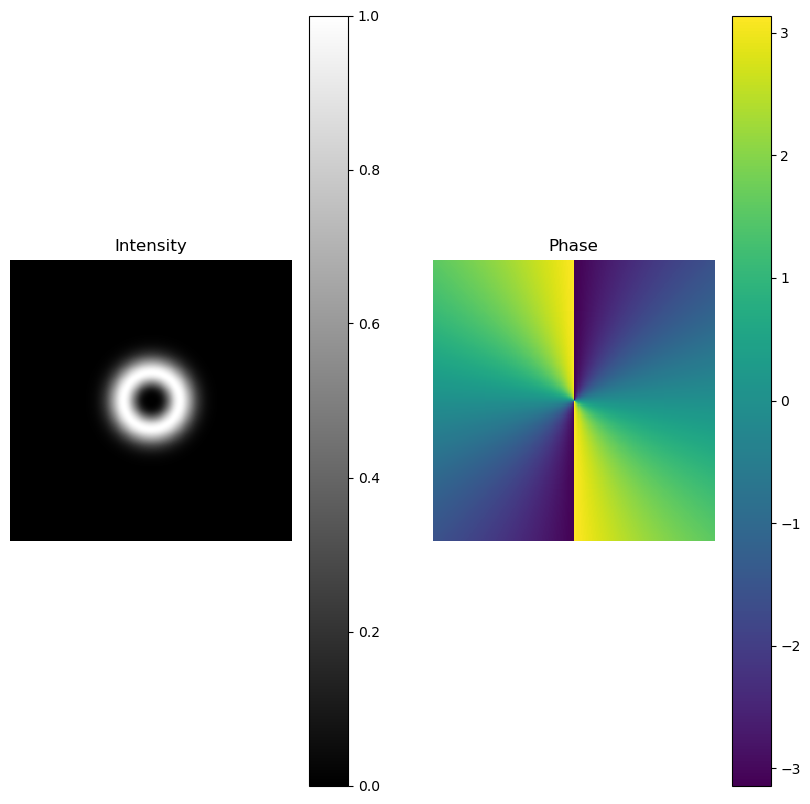

In [145]:
# Define the coordinate space 

la = 0.5*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
maxx=2.5 * mm # Full length of the numerical window (m)
N=256 # [Number of points per dimension]

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)

# Generating an LG mode as a test
field = LG(r, phi, 2, 0, 0.25*mm,h,0,k)/np.max(np.abs(field))
field = field / np.max(np.abs(field))
TotInt(field)

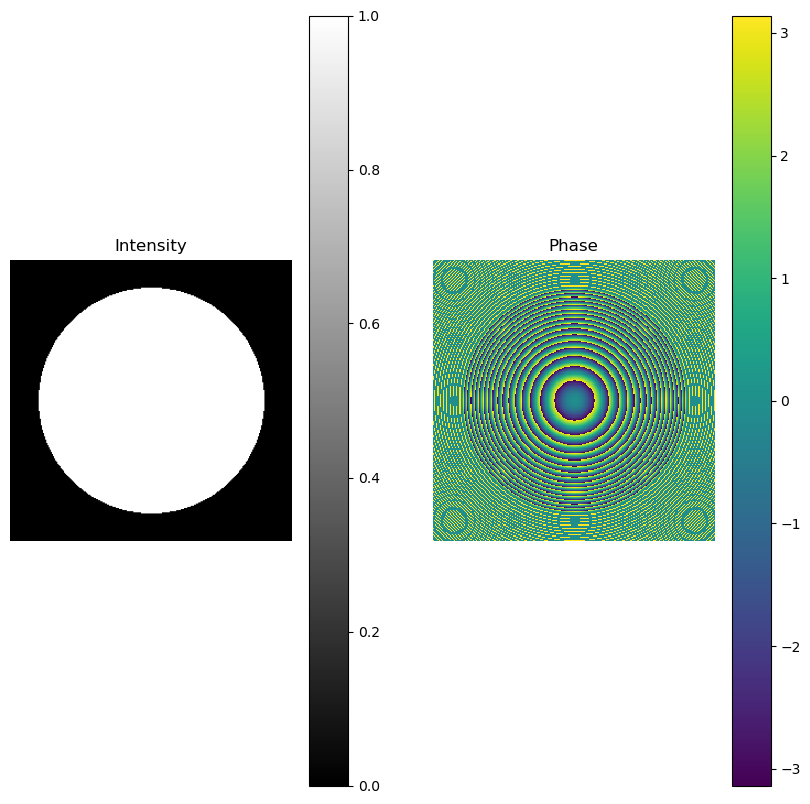

In [146]:
def lens_phase(rr,lens_rad, k, f):
    t = 1
    pupil_func = (np.where(rr**2 < lens_rad**2,t, np.zeros_like(xx)))
    return pupil_func*np.exp(-1j*(2*k/f)*(r)**2)

lens = lens_phase(r,1*mm, k,25*cm)
TotInt(lens)

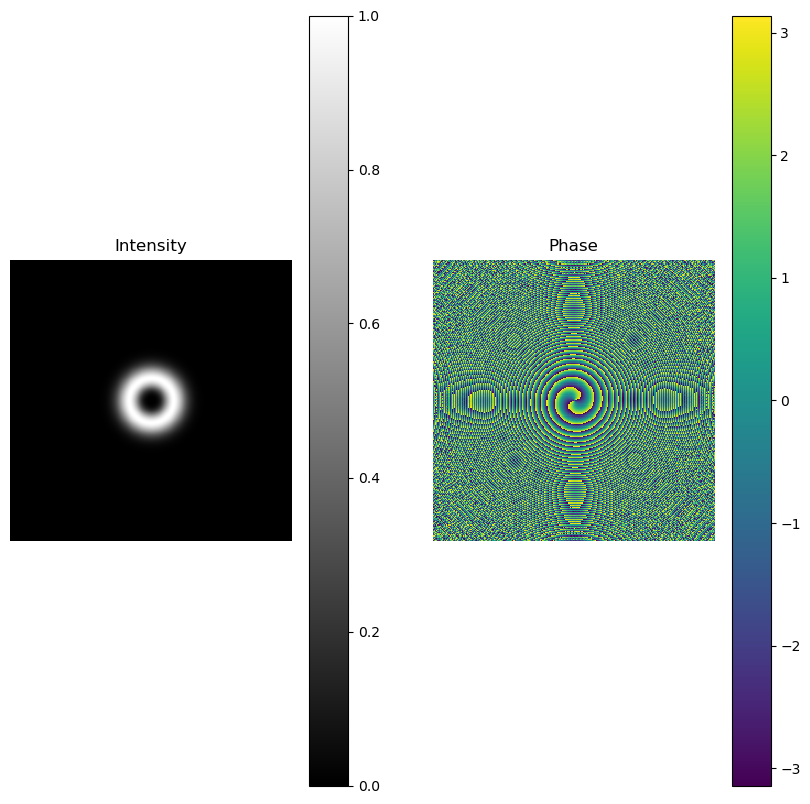

In [148]:
prop_dist = 25*cm

temp = field*lens

field_lens,_ = propFF(temp, maxx, la, prop_dist)

# Propagate the lens field in steps

field_lens = field_lens/np.max(np.abs(field_lens))

TotInt(field_lens)


In [ ]:
field_lens_invFourier = propTF(field, 2*maxx, la, 2)*lens_phase(xx, yy, k, 1)
field_final = propTF(field_lens_invFourier, 2*maxx, la, 1)

TotInt(field_final)

This function produces sets of output channel fields as output. 

In [106]:
def output_chan(X, Y, w0, maxx, num_of_spots, k):
    N = len(X)
    spot_loc_x = []
    spot_loc_y = []
    
    for ii in range(num_of_spots):
        spot_loc_x.append(np.random.uniform(-maxx+w0,maxx-w0))
        spot_loc_y.append(np.random.uniform(-maxx+w0,maxx-w0))
    
    print(spot_loc_x)
    
    fields = np.empty((num_of_spots, N, N), dtype=np.complex64)
    # Space definition 
    for ii in range(num_of_spots):
        
        X=np.linspace(-maxx,maxx,N) + spot_loc_x[ii]
        Y=np.linspace(-maxx,maxx,N) + spot_loc_y[ii]
        h=np.abs(X[1]-X[2]) # Step size
        xx,yy=np.meshgrid(X,Y)
        r, phi= cart2pol(xx,yy)
        
        fields[ii] = LG(r, phi, 0, 0, w0, h, 0, k)
    
    return fields

funny = output_chan(X,Y,0.5,maxx,5,k)


[-1.2787308783077778, -2.3490906768791837, 2.2413922457999806, -2.4814069321186616, -0.2228624513816091]


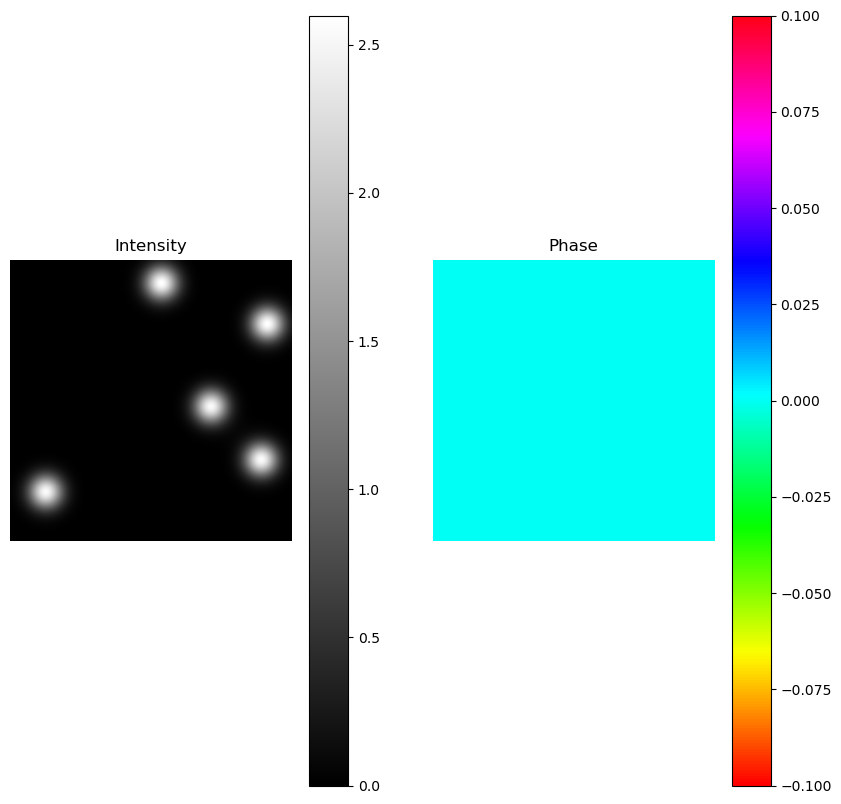

In [108]:
totalField = 


TotInt(np.sum(funny, axis=0))

Verifying our propagation of LG modes

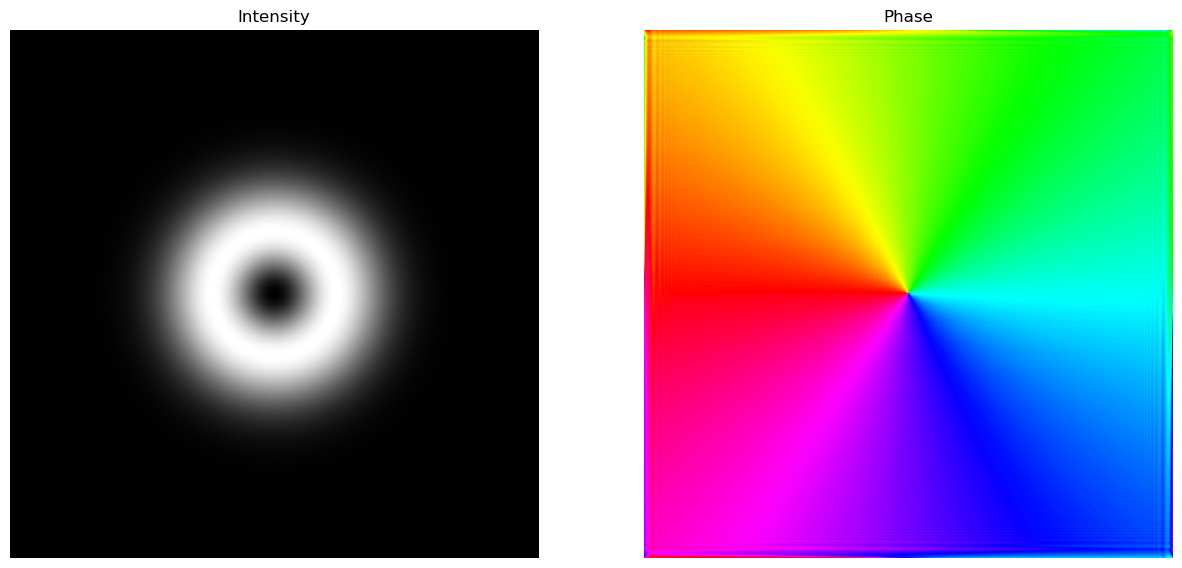

In [42]:
LG2 = propTF(field,2*maxx, la, 1)
TotInt(LG2)

Create a totally random phase modulation 

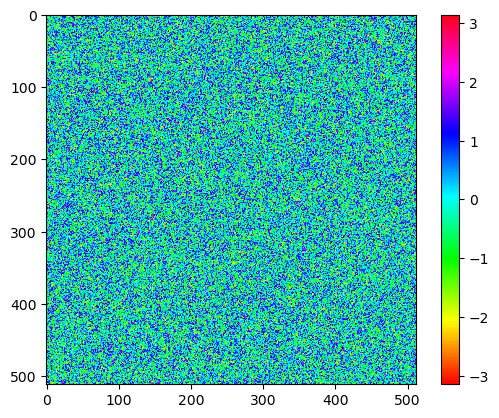

In [61]:
random_phase = np.random.uniform(-np.pi, np.pi, size=(N,N))
plt.imshow(random_phase, cmap='hsv')
plt.colorbar()

Our output channels are tiny gaussian spots. Let's plot and see

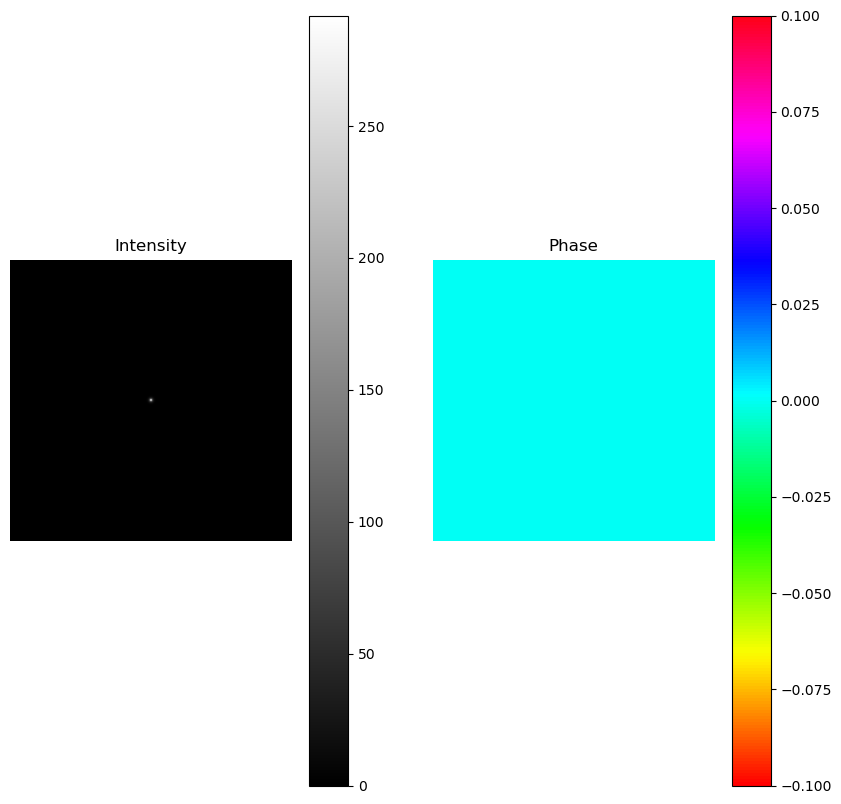

In [66]:
def output_chan(X, Y,)